В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

https://github.com/martakocubaj/python_for_ds_tasks/blob/main/process_bank_churn.py - Посилання най файл, тільки я ще перед самою роботою з цих домашнім завданням там замість StandardScaler дала MinMaxScaler на числові ознаки, бо прочитала що для кнн класифікації так краще, але змінила це у файлі тільки для цього випадку, але після цього зміню мабуть назад.

In [38]:
import pandas as pd
import numpy as np
from process_bank_churn import preprocess_data, preprocess_new_data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV,  RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import time

In [2]:
raw_df = pd.read_csv('train.csv')
data = preprocess_data(raw_df, scale_numeric=True)
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']
X_train

,CreditScore,Age,Tenure,Balance,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,NumOfProducts_1.0,NumOfProducts_2.0,NumOfProducts_3.0,NumOfProducts_4.0,HasCrCard,IsActiveMember
8263,0.632458,0.259259,0.5,0.622726,0.433916,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
14199,0.479714,0.259259,0.4,0.571232,0.888712,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1856,0.591885,0.074074,0.4,0.000000,0.813017,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3013,0.653938,0.555556,0.3,0.000000,0.599071,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
8266,0.632458,0.314815,0.7,0.000000,0.502109,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.482100,0.277778,0.4,0.000000,0.617686,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7687,0.510740,0.277778,0.3,0.417325,0.675392,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
8143,0.453461,0.203704,0.8,0.000000,0.667682,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
11512,0.379475,0.444444,0.7,0.000000,0.363197,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [5]:
?KNeighborsClassifier

In [12]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

train_probs = knn.predict_proba(X_train)[:, 1]
val_probs = knn.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9591
Validation AUROC: 0.8654


Отримана модель дає нам high variance, тобто перенавчання, дані на тренувальних передбачаються на 10% точніше за валідаційні.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [14]:
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [16]:
knn_best = knn_gs.best_estimator_
knn_best

KNeighborsClassifier(n_neighbors=7)

In [17]:
knn_best.fit(X_train, train_targets)

train_probs = knn_best.predict_proba(X_train)[:, 1]
val_probs = knn_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9510
Validation AUROC: 0.8812


Модель уже працює трішки краще, але все ще присутнє трохи перенавчання. Модель працює гірше ніж у попередньому завданні із деревами.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [34]:
dt_params = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}

In [35]:
start_time = time.time()

dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=3,
    scoring='roc_auc'
)

dt_grid_search.fit(X_train, train_targets)

end_time = time.time()

print(f"{end_time - start_time:.2f} seconds")

dt_best = dt_grid_search.best_estimator_
dt_best

3.63 seconds


DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10, random_state=42)

In [36]:
dt_best.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10, random_state=42)

In [37]:
train_probs = dt_best.predict_proba(X_train)[:, 1]
val_probs = dt_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9004
Validation AUROC: 0.9022


Ця модель все ще гірша за мою ручну модель, але тут уже зрівнялися якості моделі тренувальних і валідаційних даних. У моїй ручній моделі я задала вищий max_leaf_nodes.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [42]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [40]:
?RandomizedSearchCV

In [44]:
start_time = time.time()

search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    params_dt,
    n_iter = 40,
    cv=3,
    scoring="roc_auc",
    random_state=42
)

search.fit(X_train, train_targets)

end_time = time.time()

print(f"{end_time - start_time:.2f} seconds")

dt_random_search_best = search.best_estimator_
dt_random_search_best

1.09 seconds


DecisionTreeClassifier(criterion='entropy', max_depth=16, max_leaf_nodes=14,
                       min_samples_leaf=2, min_samples_split=20,
                       random_state=42)

In [45]:
train_probs = dt_random_search_best.predict_proba(X_train)[:, 1]
val_probs = dt_random_search_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9158
Validation AUROC: 0.9167


In [46]:
?DecisionTreeClassifier

Ця модель працює краще за попередню. Тут ми змінили критерій по вибору розділення дерева, і включили ще можливості вибору різни параметрів для min_samples_leaf і min_samples_split, і таким чином змінилися і наші два параметри які ми попередньо уже намагалися оптимально знайти.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [50]:
test_raw_df = pd.read_csv('test.csv')
X_test = preprocess_new_data(
    test_raw_df, 
    data['scaler'], 
    data['encoder'])

submission_df = pd.DataFrame({
    'id': test_raw_df['id'],
    'Exited': dt_random_search_best.predict_proba(X_test)[:,1]
})

submission_df.to_csv('submission_with_CV.csv', index=False)

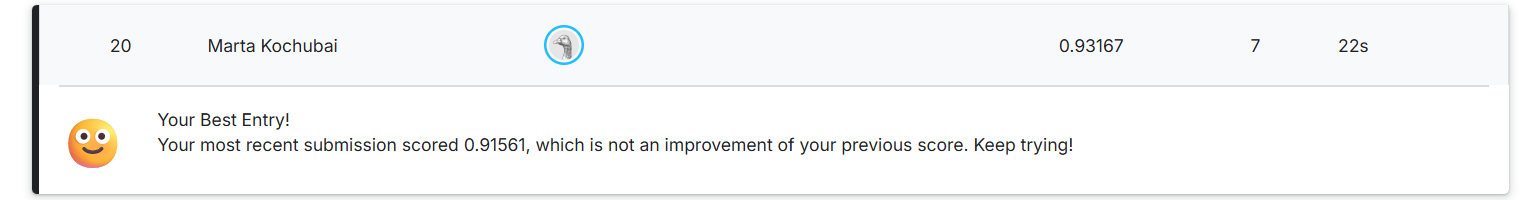